# Probador de ondas ideales Plenas del TDG


--- Parámetros de la onda ---
Tensión pico registrada (Ue): 1026.423 kV
Tensión pico de Ensayo (Ut): 1000.169 kV
Tiempo de Frente (T1):  1.080 µs
Tiempo de Cola (T2):    48.357 µs
Overshoot Relativo:     4.46 %


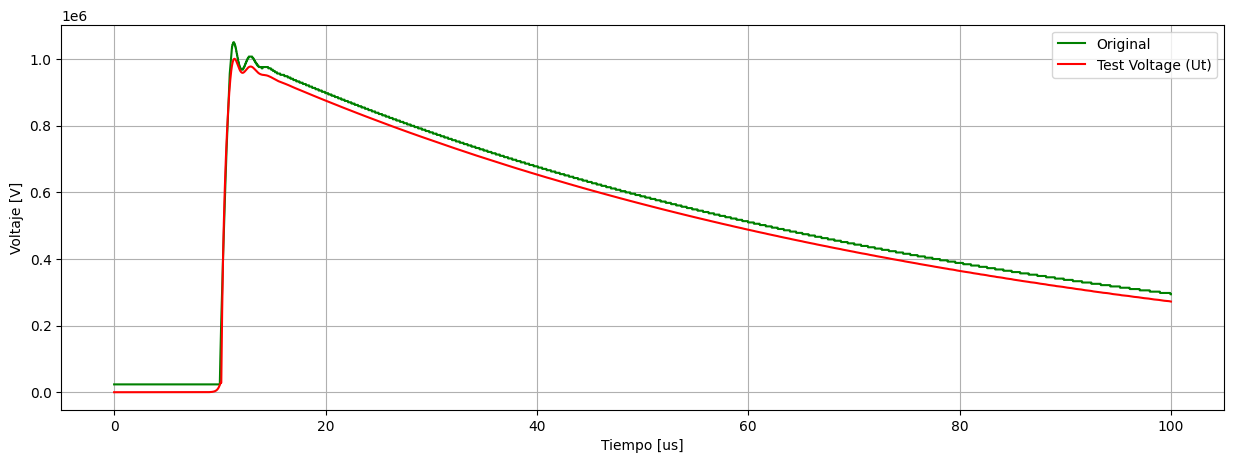

In [14]:
from pathlib import Path
import matplotlib.pyplot as plt
from file_manager import *
from impulse_analyzer import *
from report_2 import *

if __name__ == "__main__":
    gestor = FileManager()
    calibration_file = Path.cwd().parent / "Calibracion" / "IEC61083_2" / "LI-A3.txt"
    
    try:
        metadata, waveform = gestor.read_TDG_file(calibration_file)
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo '{calibration_file}'")
    except Exception as e:
        print(f"Error al procesar el archivo: {e}")

    analyzer = LightningImpulseAnalyzer(waveform, metadata['sampling_period'], sigma_fit=4.90)
    analyzer.impulse_type = "full"

    bandera = True
    if bandera:
        analyzer.ref_lightning_impulse()

        print("\n--- Parámetros de la onda ---")
        print(f"Tensión pico registrada (Ue): {analyzer.Ue/1e3:.3f} kV")
        print(f"Tensión pico de Ensayo (Ut): {analyzer.results['Ut']/1e3:.3f} kV")
        print(f"Tiempo de Frente (T1):  {analyzer.results['T1']*1e6:.3f} µs")
        print(f"Tiempo de Cola (T2):    {analyzer.results['T2']*1e6:.3f} µs")
        print(f"Overshoot Relativo:     {analyzer.results['OS']:.2f} %")

        # Graficar resultado final:
        plt.figure(figsize=(15, 5))
        plt.plot(analyzer.time_axis*1e6, analyzer.raw_voltage, color='green', label='Original')
        plt.plot(analyzer.time_axis*1e6, analyzer.test_voltage_curve, color='red', linestyle='-', label='Test Voltage (Ut)')
        #plt.plot(analyzer.time_axis*1e6, analyzer.base_curve * analyzer.factor, color='blue', linestyle='--', label='Base Curve (Um)')
        plt.xlabel("Tiempo [us]")
        plt.ylabel("Voltaje [V]")
        plt.legend()
        plt.grid(True)
        plt.show()

    else:
        # Paso 0: Dibujar onda original.
        plot_1_waveform(analyzer.time_axis*1e6, analyzer.raw_voltage/1e3, 
                        "Curva original", "Curva original")

        # Paso 1: Obtener la curva registrada compensada en offset.
        analyzer._remove_offset()
        print(f"Offset removido: {analyzer.offset_value/1000:.2f} kV")
        plot_1_waveform(analyzer.time_axis*1e6, analyzer.zeroed_curve/1e3, 
                        "Curva compensada en offset", "Curva registrada compensada en offset")

        # Paso 2: Detectar pico y normalizar.
        analyzer._polarity_normalization()
        analyzer._normalize_waveform()
        print(f"Pico detectado: {analyzer.peak_value/1000:.2f} kV")
        print(f"Polaridad: {analyzer.polarity}")
        # Graficar la señal normalizada
        plot_1_waveform(analyzer.time_axis*1e6, analyzer.zeroed_curve_abs/1e3, 
                        "Curva normalizada", "Curva normalizada")

        # Paso 3: Recortar la señal entre 20 % del frente y 40 % de la cola.
        analyzer._cutting_signal()
        print(f"Muestras seleccionadas para ajuste = {len(analyzer.fit_voltage)}.")
        plot_2_waveform(analyzer.time_axis*1e6, analyzer.zeroed_curve_abs/1e3, "Onda completa", 
                        analyzer.fit_time*1e6, analyzer.fit_voltage/1e3, 
                        "Datos para ajuste (0.2 a 0.4)", "Curva recortada para ajuste")

        # Paso 4: Ajuste de la señal recortada con función de doble exponencial.
        analyzer._fit_base_curve()
        # Graficar la curva de ajuste encontrada junto con los datos recortados.
        plot_2_waveform(analyzer.fit_time*1e6, analyzer.fit_voltage/1e3, "Datos para ajuste", 
                        analyzer.fit_time*1e6, analyzer.fitted_curve/1e3, 
                        "Curva de Ajuste", "Ajuste de curva base")

        # Paso 5: Obtener la curva base.
        analyzer._construct_base_curve()
        print(f"Máximo de tensión de la curva base (Ub): {analyzer.Ub/1000:.2f} kV")
        plot_2_waveform(analyzer.time_axis*1e6, analyzer.zeroed_curve_abs/1e3, "Curva compensada en offset", 
                        analyzer.time_axis*1e6, analyzer.base_curve/1e3, 
                        "Curva base", "Curva compensada en offset y curva base")

        # Paso 6: Calcular la curva residual.
        analyzer._calculate_residual_curve()
        plot_1_waveform(analyzer.time_axis*1e6, analyzer.residual_curve/1e3, 
                        "Curva residual", "Curva residual")

        # Paso 7: Filtrar la curva residual.
        analyzer._filter_to_residual()
        plot_1_waveform(analyzer.time_axis*1e6, analyzer.filtered_residual/1e3, 
                        "Curva residual filtrada", "Curva residual filtrada")

        # Paso 8: Calcular la curva de tensión de ensayo Ut(t) y su valor máximo Ut.
        analyzer._construct_test_voltage_curve()
        print(f"Valor máximo de la tensión de ensayo (Ut): {analyzer.Ut/1000:.2f} kV")
        plot_1_waveform(analyzer.time_axis*1e6, analyzer.test_voltage_curve/1e3,
                         "Curva de tensión de ensayo", "Curva de tensión de ensayo")
        
        plot_2_waveform(analyzer.time_axis*1e6, analyzer.raw_voltage/1e3, "Curva original", 
                        analyzer.time_axis*1e6, analyzer.test_voltage_curve/1e3, "Curva de tensión de ensayo", "Comparativa final")
        
        # Paso 9: Calcular los parámetros característicos de la onda de impulso.
        analyzer._calculate_parameters()

        print("Parámetros característicos de la onda de impulso:")
        print(f"Ut = {analyzer.results['Ut']/1e3:.2f} kV")
        print(f"T1 = {analyzer.results['T1']*1e6:.2f} µs")
        print(f"T2 = {analyzer.results['T2']*1e6:.2f} µs")
        print(f"OS = {analyzer.results['OS']:.2f} %")
        print(f"Ue = {analyzer.Ue/1e3:.2f} kV")
        print(f"Ub = {analyzer.Ub/1e3:.2f} kV")

# Probador de ondas reales del LAT

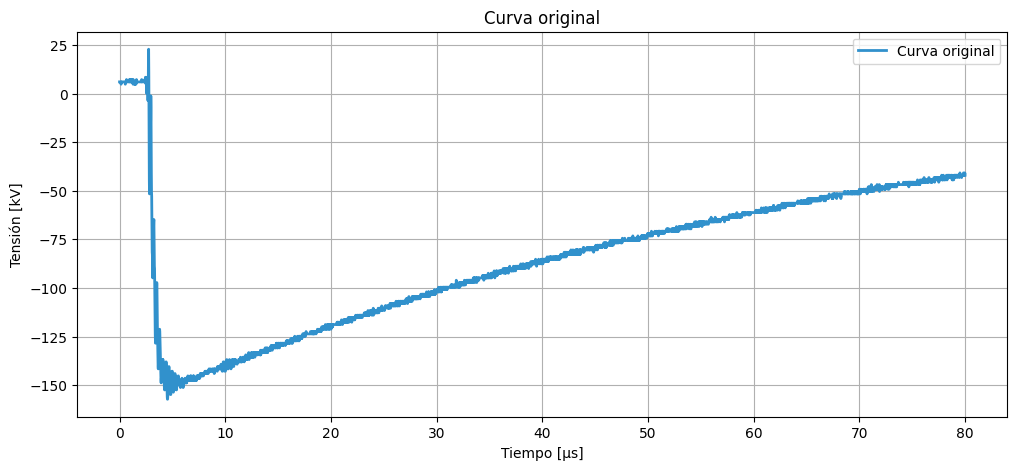

Offset removido: 6.03 kV


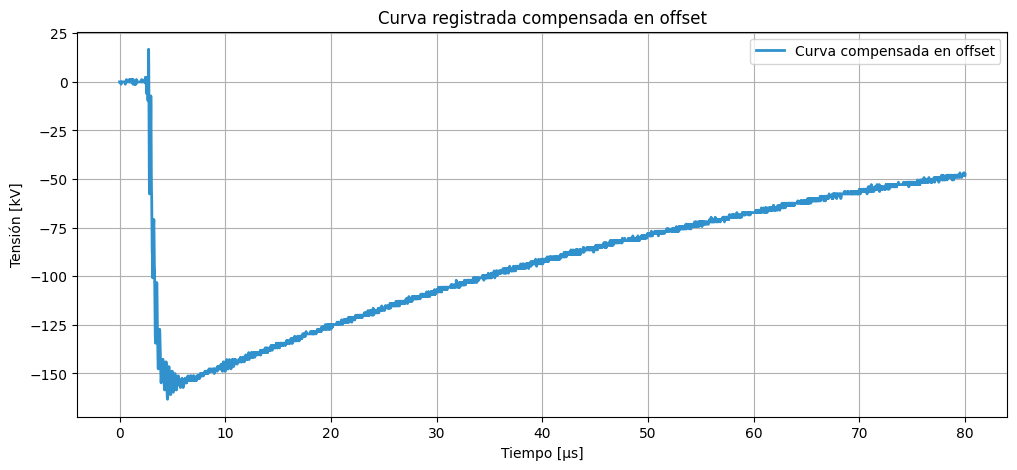

Pico detectado: 163.26 kV
Polaridad: Negativa


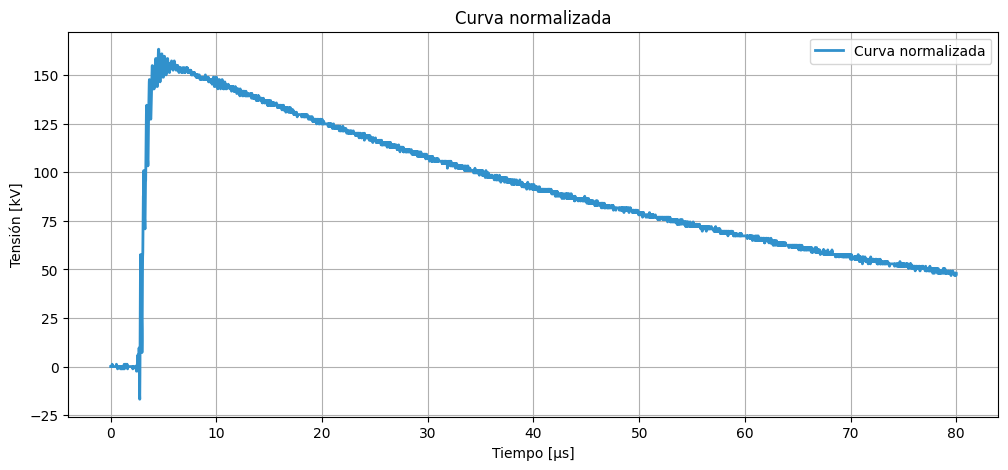

Muestras seleccionadas para ajuste = 3609.


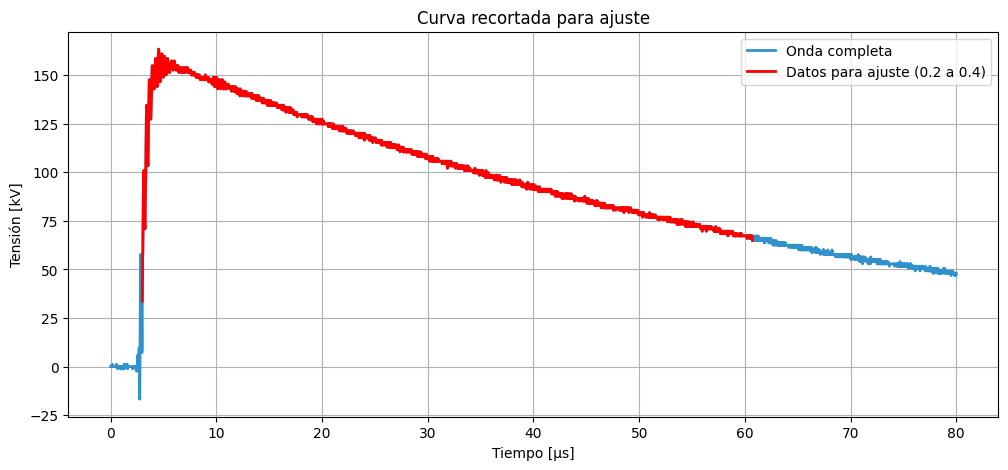

Máximo de tensión de la curva base (Ub): 156.35 kV


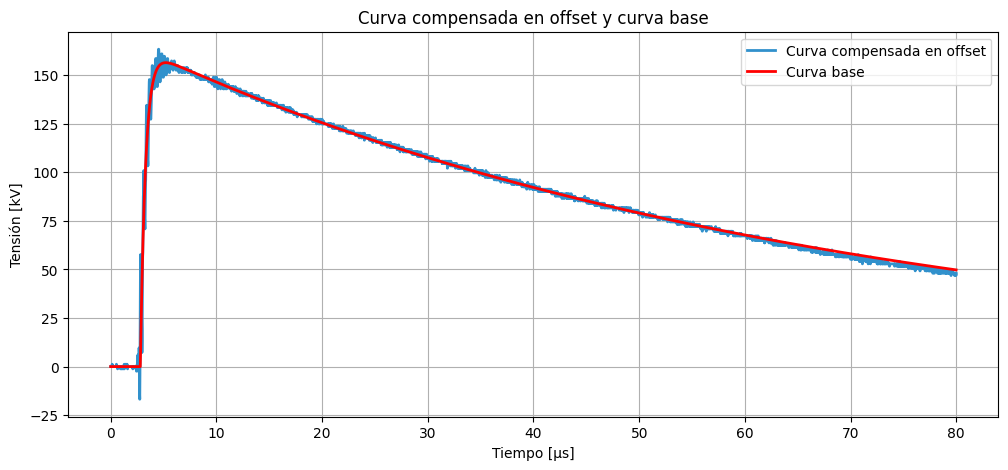

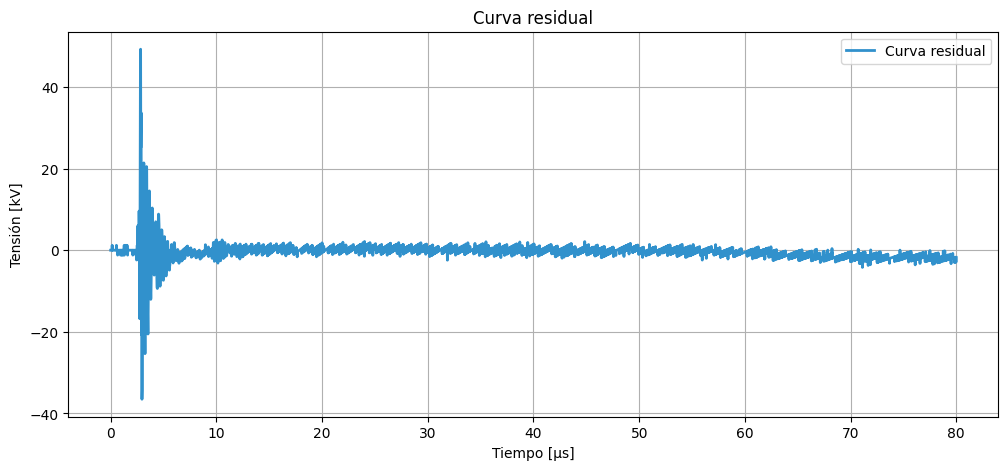

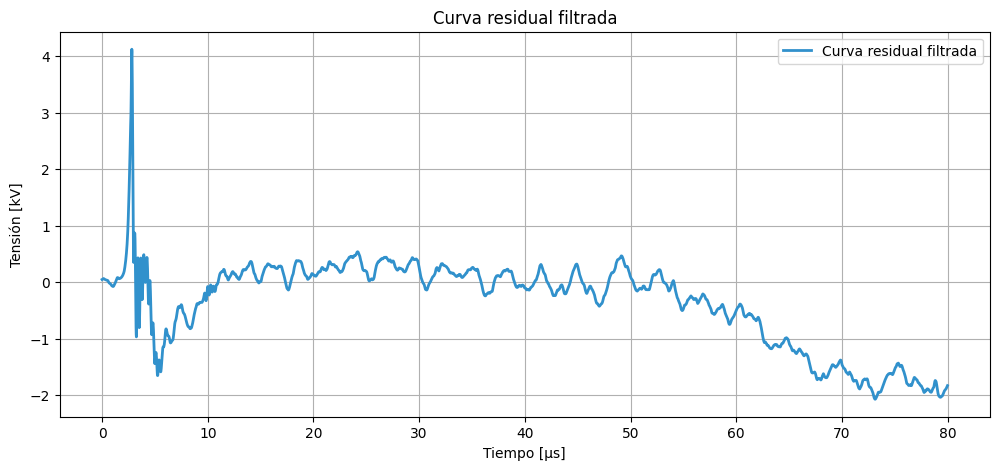

Valor máximo de la tensión de ensayo (Ut): -155.14 kV


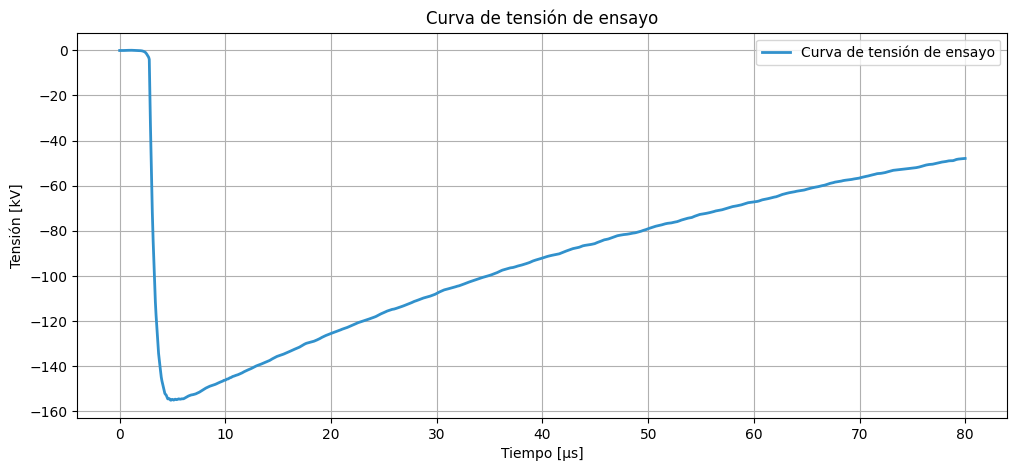

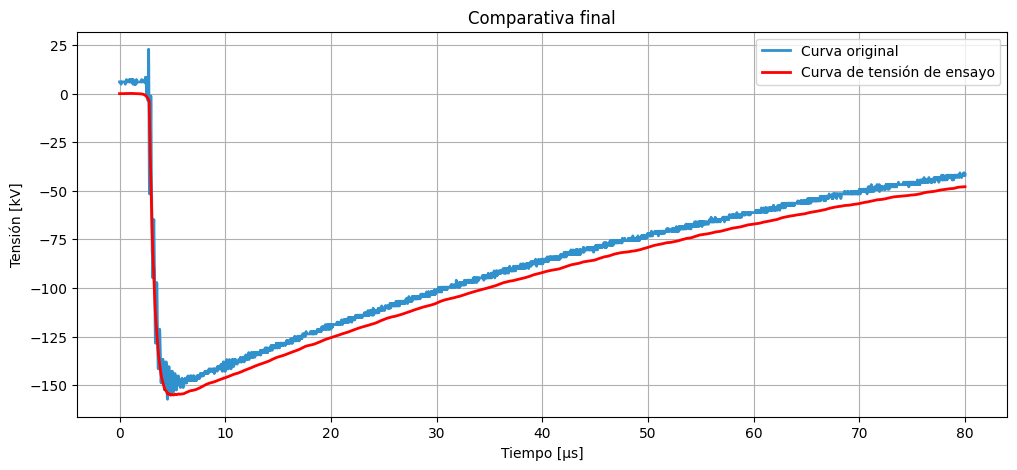

Parámetros característicos de la onda de impulso:
Ut = -155.14 kV
T1 = 1.40 µs
T2 = 48.52 µs
OS = 4.23 %
Ue = -163.26 kV
Ub = 156.35 kV


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from file_manager import *
from impulse_analyzer import *
from report_2 import *

# --- Configuración de Exportación ---
EXPORT_DIR: Path = Path.cwd().parent / "Exportaciones" / "LAT"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

if __name__ == "__main__":
    gestor = FileManager()
    calibration_file = Path.cwd().parent / "Calibracion" / "LAT" / "LAT_1n.txt"
    
    try:
        metadata, waveform = gestor.read_TDG_file(calibration_file)
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo '{calibration_file}'")
    except Exception as e:
        print(f"Error al procesar el archivo: {e}")

    analyzer = LightningImpulseAnalyzer(waveform, metadata['sampling_period'], sigma_fit=0.5)
    analyzer.impulse_type = "full"

    bandera = False
    if bandera:
        analyzer.ref_lightning_impulse()

        print("\n--- Parámetros de la onda ---")
        print(f"Tensión pico registrada (Ue): {analyzer.Ue/1e3:.3f} kV")
        print(f"Tensión pico de Ensayo (Ut): {analyzer.results['Ut']/1e3:.3f} kV")
        print(f"Tiempo de Frente (T1):  {analyzer.results['T1']*1e6:.3f} µs")
        print(f"Tiempo de Cola (T2):    {analyzer.results['T2']*1e6:.3f} µs")
        print(f"Overshoot Relativo:     {analyzer.results['OS']:.2f} %")

        # Graficar resultado final:
        plt.figure(figsize=(15, 8), dpi=100)
        plt.plot(analyzer.time_axis*1e6, analyzer.raw_voltage, color="#4aa7e1", linewidth=2, label='Original')
        plt.plot(analyzer.time_axis*1e6, analyzer.test_voltage_curve, color='red', linewidth=4, label='Test Voltage')
        #plt.plot(analyzer.time_axis*1e6, analyzer.base_curve * analyzer.factor, color='blue', linestyle='--', label='Base Curve (Um)')
        plt.xlabel("Tiempo [us]")
        plt.ylabel("Voltaje [V]")
        plt.legend()
        plt.grid(True)
        plt.show()
        
        # Exportación
        plt.savefig(EXPORT_DIR / "analisis_completo.png", bbox_inches='tight', format='png')
        plt.show()

    else:
        # Paso 0: Dibujar onda original.
        plot_1_waveform(analyzer.time_axis*1e6, 
                        analyzer.raw_voltage/1e3, 
                        "Curva original", 
                        "Curva original",
                        save_path=EXPORT_DIR / "0_curva_original.png")

        # Paso 1: Obtener la curva registrada compensada en offset.
        analyzer._remove_offset()
        print(f"Offset removido: {analyzer.offset_value/1000:.2f} kV")
        plot_1_waveform(analyzer.time_axis*1e6, 
                        analyzer.zeroed_curve/1e3, 
                        "Curva compensada en offset", 
                        "Curva registrada compensada en offset",
                        save_path=EXPORT_DIR / "1_offset_removido.png")

        # Paso 2: Detectar pico y normalizar.
        analyzer._polarity_normalization()
        analyzer._normalize_waveform()
        print(f"Pico detectado: {analyzer.peak_value/1000:.2f} kV")
        print(f"Polaridad: {analyzer.polarity}")
        # Graficar la señal normalizada
        plot_1_waveform(analyzer.time_axis*1e6, 
                        analyzer.zeroed_curve_abs/1e3, 
                        "Curva normalizada", 
                        "Curva normalizada",
                        save_path=EXPORT_DIR / "2_curva_normalizada.png")

        # Paso 3: Recortar la señal entre 20 % del frente y 40 % de la cola.
        analyzer._cutting_signal()
        print(f"Muestras seleccionadas para ajuste = {len(analyzer.fit_voltage)}.")
        plot_2_waveform(analyzer.time_axis*1e6, 
                        analyzer.zeroed_curve_abs/1e3, 
                        "Onda completa", 
                        analyzer.fit_time*1e6, 
                        analyzer.fit_voltage/1e3, 
                        "Datos para ajuste (0.2 a 0.4)", 
                        "Curva recortada para ajuste",
                        save_path=EXPORT_DIR / "3_curva_recortada.png")

        # Paso 4: Obtener la curva base.
        analyzer._fit_base_curve()
        analyzer._construct_base_curve()
        print(f"Máximo de tensión de la curva base (Ub): {analyzer.Ub/1000:.2f} kV")
        plot_2_waveform(analyzer.time_axis*1e6, 
                        analyzer.zeroed_curve_abs/1e3, 
                        "Curva compensada en offset", 
                        analyzer.time_axis*1e6, 
                        analyzer.base_curve/1e3, 
                        "Curva base", 
                        "Curva compensada en offset y curva base",
                        save_path=EXPORT_DIR / "4_curva_base.png")

        # Paso 5: Calcular la curva residual.
        analyzer._calculate_residual_curve()
        plot_1_waveform(analyzer.time_axis*1e6, 
                        analyzer.residual_curve/1e3, 
                        "Curva residual", 
                        "Curva residual",
                        save_path=EXPORT_DIR / "5_curva_residual.png")

        # Paso 6: Filtrar la curva residual.
        analyzer._filter_to_residual()
        plot_1_waveform(analyzer.time_axis*1e6, 
                        analyzer.filtered_residual/1e3, 
                        "Curva residual filtrada", 
                        "Curva residual filtrada",
                        save_path=EXPORT_DIR / "6_residual_filtrada.png")

        # Paso 8: Calcular la curva de tensión de ensayo Ut(t) y su valor máximo Ut.
        analyzer._construct_test_voltage_curve()
        print(f"Valor máximo de la tensión de ensayo (Ut): {analyzer.Ut/1000:.2f} kV")
        plot_1_waveform(analyzer.time_axis*1e6, 
                        analyzer.test_voltage_curve/1e3,
                        "Curva de tensión de ensayo", 
                        "Curva de tensión de ensayo",
                        save_path=EXPORT_DIR / "7_tension_ensayo_final.png")
    
        plot_2_waveform(analyzer.time_axis*1e6, 
                        analyzer.raw_voltage/1e3, 
                        "Curva original", 
                        analyzer.time_axis*1e6, 
                        analyzer.test_voltage_curve/1e3, 
                        "Curva de tensión de ensayo", 
                        "Comparativa final",
                        save_path=EXPORT_DIR / "8_curva_original_ensayo.png")
        
        # Paso 9: Calcular los parámetros característicos de la onda de impulso.
        analyzer._calculate_parameters()

        print("Parámetros característicos de la onda de impulso:")
        print(f"Ut = {analyzer.results['Ut']/1e3:.2f} kV")
        print(f"T1 = {analyzer.results['T1']*1e6:.2f} µs")
        print(f"T2 = {analyzer.results['T2']*1e6:.2f} µs")
        print(f"OS = {analyzer.results['OS']:.2f} %")
        print(f"Ue = {analyzer.Ue/1e3:.2f} kV")
        print(f"Ub = {analyzer.Ub/1e3:.2f} kV")

# Probador de ondas ideales Cortadas del TDG

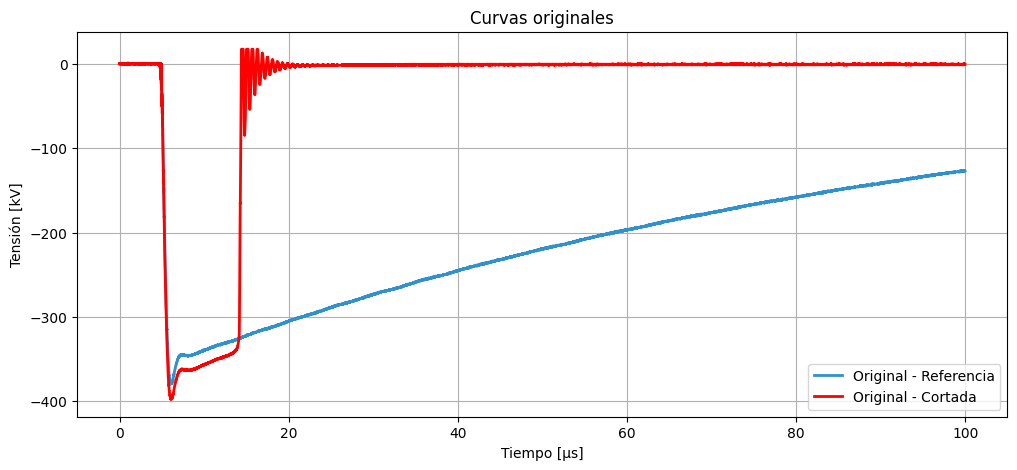

Offset removido: 0.26 kV


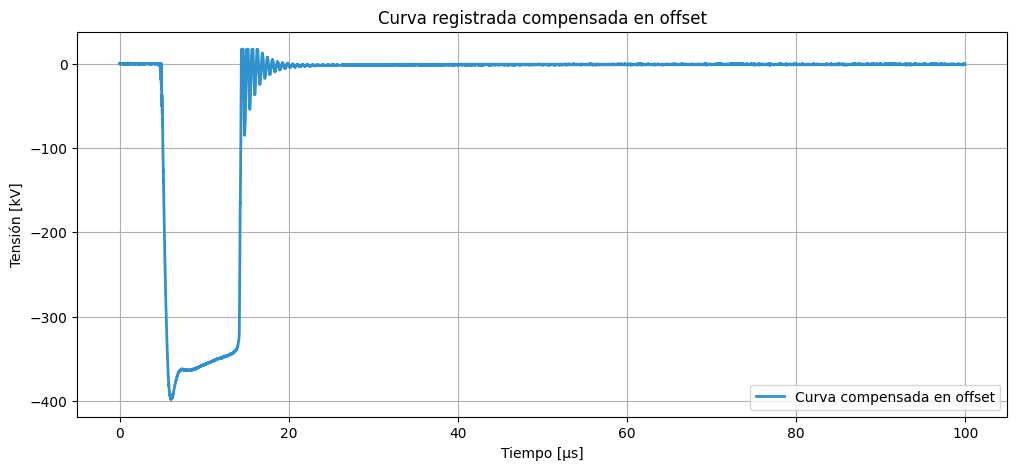

Pico detectado: 397.75 kV
Polaridad: Negativa


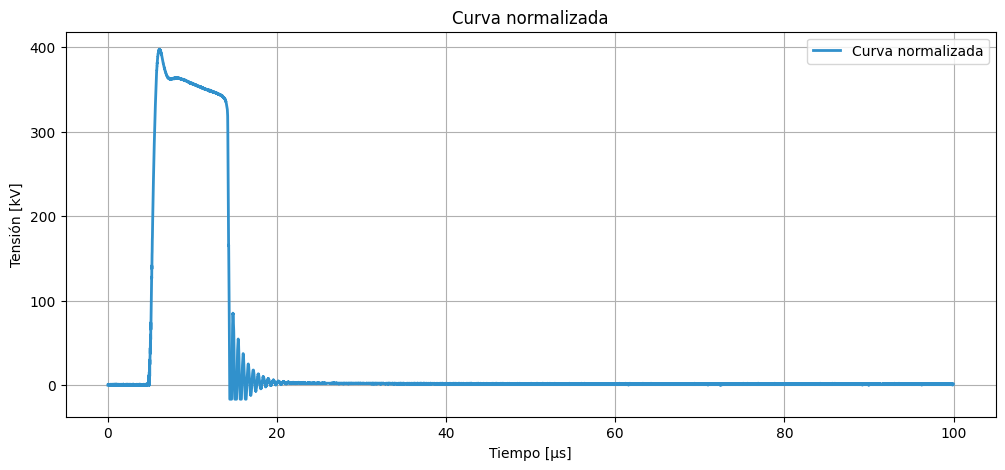

Desfase de tiempo calculado (t_L): 0.004 µs
Tipo de impulso detectado: chopped
Índice de desviación: 1431


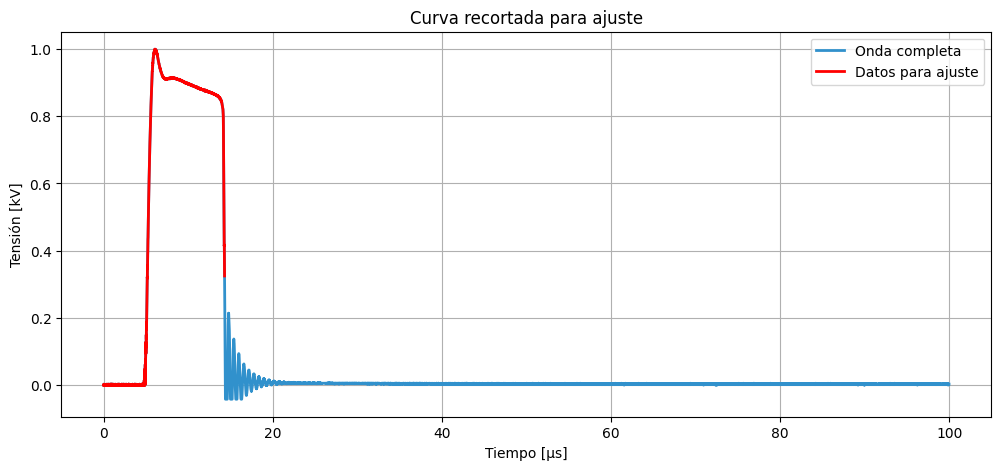

Relación de amplitudes (E): 1.0477
Máximo de tensión de la curva base (Ub): 370.29 kV


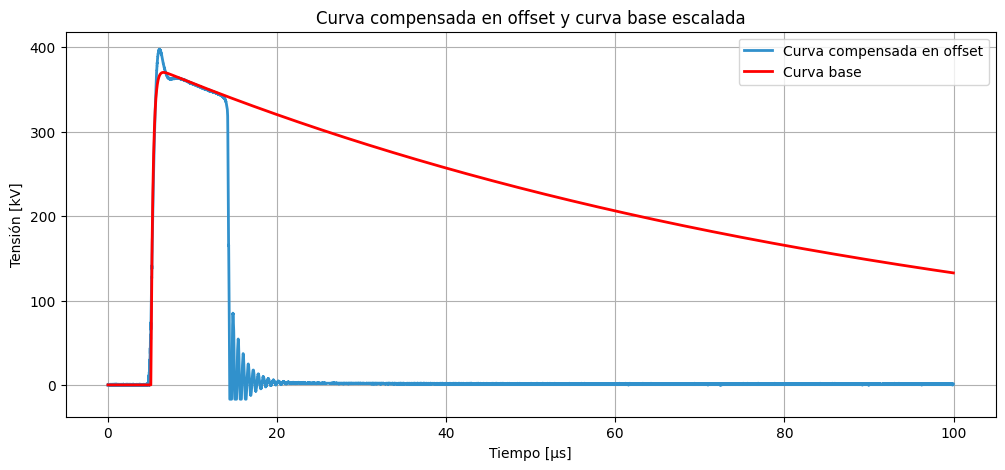

Tensión de colapso: 285.15 kV
Instante de corte algorítmico: 14.166 µs


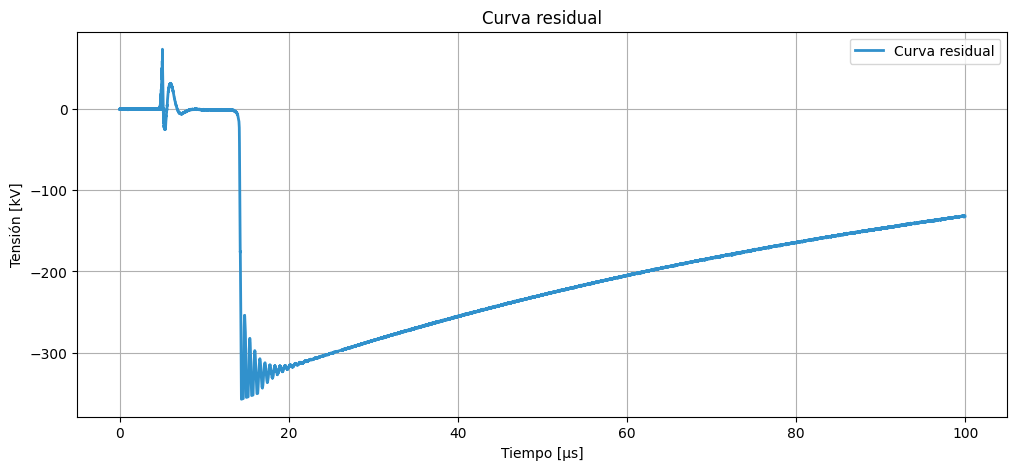

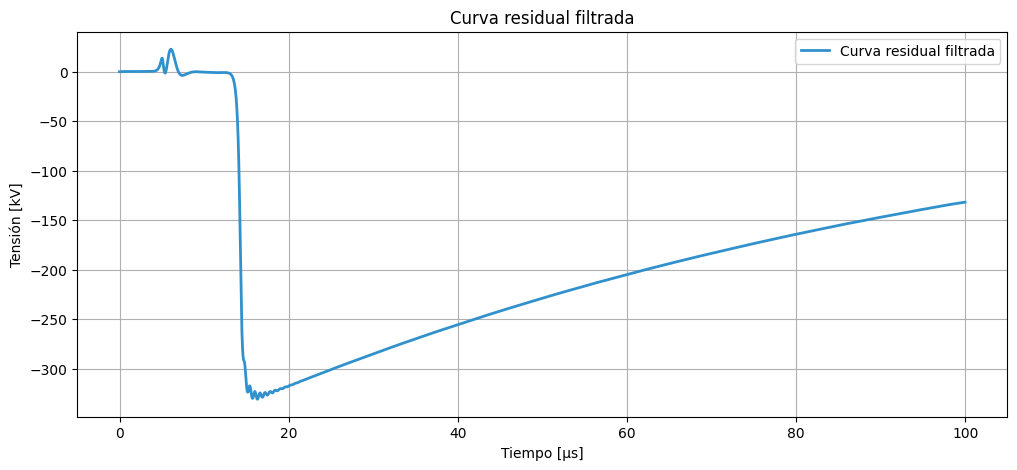

Valor máximo de la tensión de ensayo (Ut): -389.85018 kV


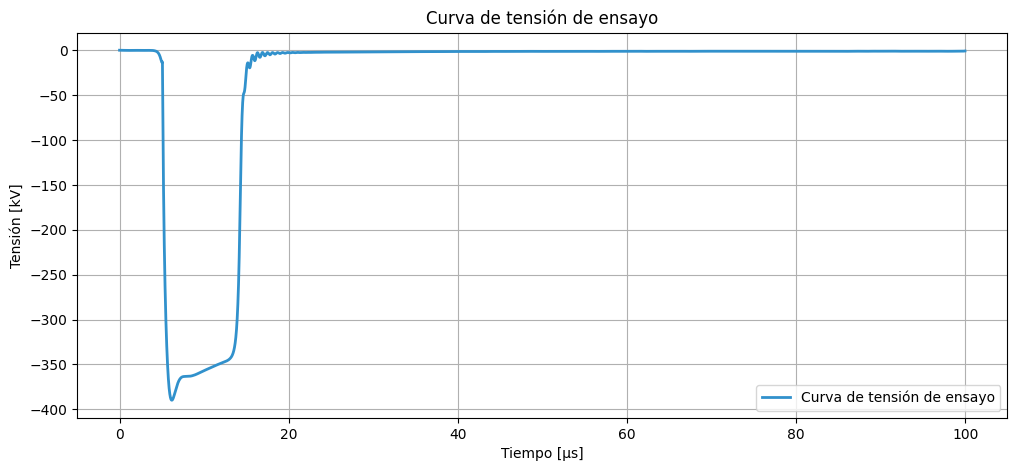

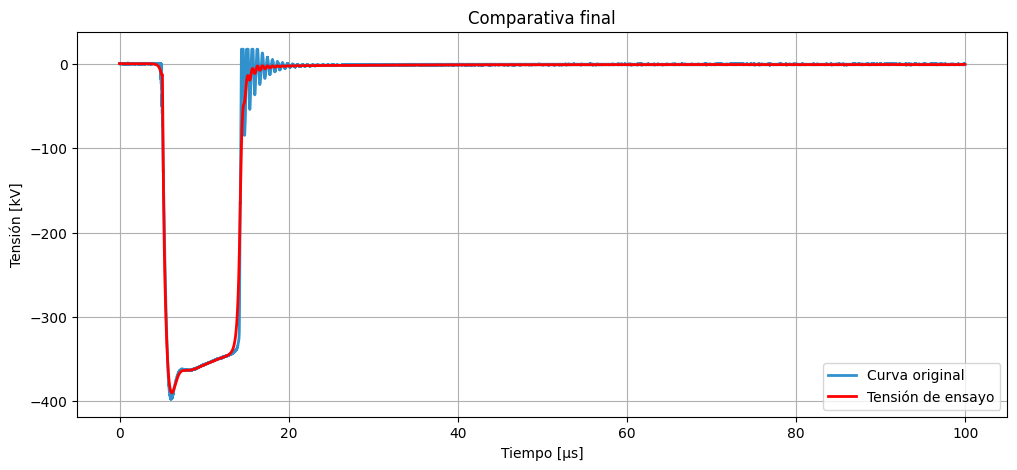


--- Parámetros característicos de la onda cortada ---
Ut = -389.85018 kV
T1 = 0.868 µs
TC = 9.267 µs
OS = 6.90 %
Ue = -397.74958 kV
Ub = 370.28528 kV


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
from file_manager import *
from impulse_analyzer import *
from report_2 import *

# --- Configuración de Exportación ---
EXPORT_DIR: Path = Path.cwd().parent / "Exportaciones" / "LIC"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

if __name__ == "__main__":
    gestor = FileManager()
    calibration_file_f = Path.cwd().parent / "Calibracion" / "IEC61083_2" / "16_bits" / "LIC-M5f.txt"
    calibration_file_c = Path.cwd().parent / "Calibracion" / "IEC61083_2" / "16_bits" / "LIC-M5c.txt"

    try:
        metadata, waveform = gestor.read_TDG_file(calibration_file_f)
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo '{calibration_file_f}'")
    except Exception as e:
        print(f"Error al procesar el archivo: {e}")

    analyzer_f = LightningImpulseAnalyzer(waveform, metadata['sampling_period'], sigma_fit=1.0)

    try:
        metadata, waveform = gestor.read_TDG_file(calibration_file_c)
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo '{calibration_file_c}'")
    except Exception as e:
        print(f"Error al procesar el archivo: {e}")

    analyzer_c = LightningImpulseAnalyzer(waveform, metadata['sampling_period'], sigma_fit=1.0)

    bandera = False
    if bandera:
        analyzer_f.ref_lightning_impulse()
        analyzer_c.lightning_impulse(analyzer_f)

        print("\n--- Parámetros de la onda ---")
        print(f"Tensión pico registrada (Ue): {analyzer_c.Ue/1e3:.5f} kV")
        print(f"Tensión pico de Ensayo (Ut): {analyzer_c.results['Ut']/1e3:.5f} kV")
        print(f"Tiempo de Frente (T1):  {analyzer_c.results['T1']*1e6:.3f} µs")
        print(f"Tiempo de Corte (TC):    {analyzer_c.results['T2']*1e6:.3f} µs")
        print(f"Overshoot Relativo:     {analyzer_c.results['OS']:.2f} %")

        # Graficar resultado final
        plt.figure(figsize=(16, 10), dpi=100)
        plt.plot(analyzer_f.time_axis*1e6, analyzer_f.raw_voltage, color="#31b71d", label='Original - Referencia')
        plt.plot(analyzer_c.time_axis*1e6, analyzer_c.raw_voltage, color='#3191cc', label='Original - Cortada')
        plt.plot(analyzer_c.time_axis*1e6, analyzer_c.test_voltage_curve, color='red', linewidth=3, label='Curva de tensión de ensayo')
        plt.xlim(0, 50)
        #plt.yticks(np.arange(-360, 1, 45)) # Paso de la grilla
        plt.xlabel("Tiempo [µs]")
        plt.ylabel("Voltaje [V]")
        plt.legend()
        plt.grid(True)
        
        # Exportación
        plt.savefig(EXPORT_DIR / "analisis_completo.png", bbox_inches='tight', format='png')
        plt.show()
    else:
        # Procesar previamente la onda de referencia plena
        analyzer_f.ref_lightning_impulse()
        
        # Paso 0: Dibujar ondas originales de referencia y cortada.
        plot_2_waveform(analyzer_f.time_axis * 1e6, 
                        analyzer_f.raw_voltage / 1e3, 
                        "Original - Referencia",
                        analyzer_c.time_axis * 1e6, 
                        analyzer_c.raw_voltage / 1e3, 
                        "Original - Cortada",
                        "Curvas originales",
                        save_path=EXPORT_DIR / "0_curvas_originales.png")

        # Paso 1: Remover offset.
        analyzer_c._remove_offset()
        print(f"Offset removido: {analyzer_c.offset_value / 1e3:.2f} kV")
        plot_1_waveform(analyzer_c.time_axis * 1e6, 
                        analyzer_c.zeroed_curve / 1e3, 
                        "Curva compensada en offset", 
                        "Curva registrada compensada en offset",
                        save_path=EXPORT_DIR / "1_offset_removido.png")

        # Paso 2: Normalización unipolar y escalar de la onda en análisis.
        analyzer_c._polarity_normalization()
        analyzer_c._normalize_waveform()
        print(f"Pico detectado: {analyzer_c.peak_value / 1e3:.2f} kV")
        print(f"Polaridad: {analyzer_c.polarity}")
        plot_1_waveform(analyzer_c.time_axis * 1e6, 
                        analyzer_c.zeroed_curve_abs / 1e3, 
                        "Curva normalizada", 
                        "Curva normalizada",
                        save_path=EXPORT_DIR / "2_curva_normalizada.png")

        # Paso 3: Determinación del desfase sub-muestral t_L e identificación de colapso dieléctrico.
        analyzer_c._find_time_lag(analyzer_f)
        analyzer_c._adjust_time_lag()
        print(f"Desfase de tiempo calculado (t_L): {analyzer_c.t_L * 1e6:.3f} µs")
        
        analyzer_c._find_deviation_point(analyzer_f)
        print(f"Tipo de impulso detectado: {analyzer_c.impulse_type}")
        print(f"Índice de desviación: {analyzer_c.idx_deviation}")

        if analyzer_c.impulse_type == "chopped":
            # Paso 4: Segmentación de la región intacta previa al colapso.
            analyzer_c._select_data_up_to_deviation()
            plot_2_waveform(analyzer_c.time_axis * 1e6, 
                            analyzer_c.norm_voltage, 
                            "Onda completa",
                            analyzer_c.chopped_front_time * 1e6, 
                            analyzer_c.chopped_front_voltage, 
                            "Datos para ajuste",
                            "Curva recortada para ajuste",
                            save_path=EXPORT_DIR / "3_curva_recortada.png")

            # Paso 5: Cálculo de la relación escalar E y síntesis de la curva base matemática Um(t).
            analyzer_c._find_amplitude_ratio(analyzer_f)
            print(f"Relación de amplitudes (E): {analyzer_c.E:.4f}")
            
            analyzer_c._scale_base_curve(analyzer_f)
            print(f"Máximo de tensión de la curva base (Ub): {analyzer_c.Ub / 1e3:.2f} kV")
            plot_2_waveform(analyzer_c.time_axis * 1e6, 
                            analyzer_c.zeroed_curve_abs / 1e3, 
                            "Curva compensada en offset", 
                            analyzer_c.aligned_time_axis * 1e6, 
                            analyzer_c.base_curve / 1e3, 
                            "Curva base", 
                            "Curva compensada en offset y curva base escalada",
                            save_path=EXPORT_DIR / "4_curva_base_escalada.png")

            # Paso 6: Aislamiento analítico del instante de corte (Chopping Instant).
            analyzer_c._find_chopping_instant()
            print(f"Tensión de colapso: {analyzer_c.U_collapse / 1e3:.2f} kV")
            print(f"Instante de corte algorítmico: {analyzer_c.Tcutting_moment * 1e6:.3f} µs")
            
        elif analyzer_c.impulse_type == "full":
            analyzer_c._cutting_signal()
            analyzer_c._fit_base_curve()
            analyzer_c._construct_base_curve()

        # Paso 7: Obtención de la curva residual bruta R(t).
        analyzer_c._calculate_residual_curve()
        plot_1_waveform(analyzer_c.time_axis * 1e6, 
                        analyzer_c.residual_curve / 1e3, 
                        "Curva residual", 
                        "Curva residual",
                        save_path=EXPORT_DIR / "5_curva_residual.png")

        # Paso 8: Filtrado digital IIR de fase cero para eliminación de perturbaciones.
        analyzer_c._filter_to_residual()
        plot_1_waveform(analyzer_c.time_axis * 1e6, 
                        analyzer_c.filtered_residual / 1e3, 
                        "Curva residual filtrada", 
                        "Curva residual filtrada",
                        save_path=EXPORT_DIR / "6_residual_filtrada.png")

        # Paso 9: Reconstrucción de la curva de tensión de ensayo Ut(t) acorde a IEC 60060-1.
        analyzer_c._construct_test_voltage_curve()
        print(f"Valor máximo de la tensión de ensayo (Ut): {analyzer_c.Ut / 1e3:.5f} kV")
        plot_1_waveform(analyzer_c.time_axis*1e6, 
                        analyzer_c.test_voltage_curve/1e3,
                        "Curva de tensión de ensayo", 
                        "Curva de tensión de ensayo",
                        save_path=EXPORT_DIR / "7_tension_ensayo_final.png")
        
        plot_2_waveform(analyzer_c.time_axis * 1e6, 
                        analyzer_c.raw_voltage / 1e3, 
                        "Curva original", 
                        analyzer_c.time_axis * 1e6, 
                        analyzer_c.test_voltage_curve / 1e3, 
                        "Tensión de ensayo", 
                        "Comparativa final",
                        save_path=EXPORT_DIR / "8_curva_original_ensayo.png")

        # Paso 10: Extracción validada de parámetros normativos.
        analyzer_c._calculate_parameters()

        print("\n--- Parámetros característicos de la onda cortada ---")
        print(f"Ut = {analyzer_c.results['Ut'] / 1e3:.5f} kV")
        print(f"T1 = {analyzer_c.results['T1'] * 1e6:.3f} µs")
        print(f"TC = {analyzer_c.results['T2'] * 1e6:.3f} µs")
        print(f"OS = {analyzer_c.results['OS']:.2f} %")
        print(f"Ue = {analyzer_c.Ue / 1e3:.5f} kV")
        print(f"Ub = {analyzer_c.Ub / 1e3:.5f} kV")